In [ ]:
#Import#

from cellpose import models, core, io, plot
from cellpose import train
from cellpose import metrics
import pickle, numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import imageio.v2 as imageio
import os, re
import skimage.filters
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from skimage import exposure, measure, filters, img_as_float
from skimage.measure import regionprops
from skimage.segmentation import watershed
from skimage.segmentation import mark_boundaries
from skimage.filters import sobel
from skimage.feature import blob_dog
from skimage import data, color, filters, segmentation, measure, morphology
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist
from scipy.spatial import distance_matrix
from scipy.ndimage import generate_binary_structure, binary_dilation
from scipy.spatial import Delaunay
from scipy.stats import qmc
import pandas as pd
from glob import glob
import cv2
import re
from collections import Counter
import time
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed

from config import Config

from nucleus_worker_Visualization import (
    process_single_nucleus,
    compute_adaptive_background_texture_nucleus_fallback,
    detect_foci_single_channel 
)
from parameter_space_generator import ParameterSpaceGenerator

from adaptive_parameter_selector import AdaptiveParameterSelector


In [2]:
# ===============================================================
# DISPLAY CURRENT CONFIGURATION
# ===============================================================
Config.print_config()

# ===============================================================
# CHECK FOLDER PATH
# ===============================================================
folder_path = Config.FOLDER_PATH

if os.path.isdir(folder_path):
    print("Folder Path exists")
    dir = os.listdir(folder_path)
    if len(dir) == 0:
        print("Empty directory")
    else:
        print("Not empty directory")
else:
    print("Folder path not found")


CURRENT CONFIGURATION
FOLDER_PATH                              = Y:\Group Members\Valentin Aubry\01_Data\Test_Data_mixed_Channels\Data1
GENERATE_NEW_PARAMETER_SPACE             = False
TRITC_PARAMETER_SPACE_PATH               = Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\TRITC_parameter_space
FITC_PARAMETER_SPACE_PATH                = Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space
N_PARAMETER_SAMPLES                      = 256
N_SOBOL_SAMPLES                          = 65536
CALIBRATION_MODE                         = True
CALIBRATION_IMAGE_LIMIT                  = 1
MANUAL_WATERSHED_THRESHOLD_TRITC         = 26.0
MANUAL_WATERSHED_THRESHOLD_FITC          = 26.0
GENERATE_VISUALIZATIONS                  = True
WATERSHED_MIN_DETECTION_PROB             = 0.0
ENABLE_TEXTURE_FILTERING                 = True
MIN_CV_THRESHOLD                         = 0.2
UNIFORM_CONTRAST_MULTIPLIER              = 1
MAX_WORKERS                          

In [3]:
# Data Loading



# High Throughput Data Loading
Cy5_data = glob(os.path.join(folder_path, '*Cy5 SEM.tif'))
DAPI_data = glob(os.path.join(folder_path, '*DAPI SEM.tif'))
DAPI_mask_data = glob(os.path.join(folder_path, '*DAPI SEM_seg.npy'))
FITC_data = glob(os.path.join(folder_path, '*FITC SEM.tif'))
TRITC_data = glob(os.path.join(folder_path, '*TRITC SEM.tif'))


# Sorting the data in case it isn't yet
Cy5_data.sort()
DAPI_data.sort()
DAPI_mask_data.sort()
FITC_data.sort()
TRITC_data.sort()


# Displaying all the data that was loaded
for i in range (len(DAPI_data)):
    print(os.path.basename(Cy5_data[i]))
    print(os.path.basename(DAPI_data[i]))
    print(os.path.basename(DAPI_mask_data[i]))
    print(os.path.basename(FITC_data[i]))
    print(os.path.basename(TRITC_data[i]))





ATR1_24h--W00032--P00015--Z00000--T00000--Cy5 SEM.tif
ATR1_24h--W00032--P00015--Z00000--T00000--DAPI SEM.tif
ATR1_24h--W00032--P00015--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00015--Z00000--T00000--FITC SEM.tif
ATR1_24h--W00032--P00015--Z00000--T00000--TRITC SEM.tif
ATR3_8h--W00053--P00016--Z00000--T00000--Cy5 SEM.tif
ATR3_8h--W00053--P00016--Z00000--T00000--DAPI SEM.tif
ATR3_8h--W00053--P00016--Z00000--T00000--DAPI SEM_seg.npy
ATR3_8h--W00053--P00016--Z00000--T00000--FITC SEM.tif
ATR3_8h--W00053--P00016--Z00000--T00000--TRITC SEM.tif
ATR4_UT--W00062--P00010--Z00000--T00000--Cy5 SEM.tif
ATR4_UT--W00062--P00010--Z00000--T00000--DAPI SEM.tif
ATR4_UT--W00062--P00010--Z00000--T00000--DAPI SEM_seg.npy
ATR4_UT--W00062--P00010--Z00000--T00000--FITC SEM.tif
ATR4_UT--W00062--P00010--Z00000--T00000--TRITC SEM.tif


In [4]:
# Loading Functions


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def analyze_brightness_percentiles(image, name):
    """
    Analyze and plot brightness percentiles from an image.
    
    Args:
        image: numpy array already scaled 0-100 (grayscale or color)
        
    Returns:
        matplotlib figure object or None if no valid pixels
    """
    # Convert numpy array to grayscale if needed
    if len(image.shape) == 3:
        pixels = np.mean(image, axis=2).flatten()
    else:
        pixels = image.flatten()
    
    # CRITICAL: Remove zero/background pixels (masked areas)
    pixels = pixels[pixels > 0]
    
    # Check if we have any valid pixels
    if len(pixels) == 0:
        print("⚠️ Warning: No non-zero pixels found in image!")
        return None
    
    # Image is already scaled 0-100, so use directly as brightness
    brightness = pixels
    
    # Create histogram with 100 bins (one per percentile)
    counts, bin_edges = np.histogram(brightness, bins=100, range=(0, 100))
    
    # Create x-axis values (center of each bin)
    percentiles = np.linspace(0, 100, 100)
    
    # Calculate statistics
    mean_brightness = np.mean(brightness)
    median_brightness = np.median(brightness)
    
    # Plot with smooth line instead of bars
    plt.figure(figsize=(12, 6))
    plt.plot(percentiles, counts, linewidth=2, color='steelblue')
    plt.fill_between(percentiles, counts, alpha=0.3, color='steelblue')  # Optional: adds shaded area under curve
    
    plt.xlabel('Brightness Percentile (0-100)', fontsize=12)
    plt.ylabel('Number of Pixels', fontsize=12)
    plt.title('Distribution of '+name+' Pixel Brightness', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, which='both')
    plt.xlim(0, 100)
    plt.xticks(np.arange(0, 101, step=2))
    
    plt.yscale('log')
    
    # Add statistics lines
    plt.axvline(mean_brightness, color='red', linestyle='--', 
                label=f'Mean: {mean_brightness:.1f}', linewidth=2)
    plt.axvline(median_brightness, color='green', linestyle='--', 
                label=f'Median: {median_brightness:.1f}', linewidth=2)
    plt.legend()
    
    plt.tight_layout()
    
    # Print summary statistics
    print(f"\n📊 Brightness Statistics:")
    print(f"  Total pixels: {len(pixels):,}")
    print(f"  Mean brightness: {mean_brightness:.2f}")
    print(f"  Median brightness: {median_brightness:.2f}")
    print(f"  Min brightness: {np.min(brightness):.2f}")
    print(f"  Max brightness: {np.max(brightness):.2f}")
    
    return plt.gcf()




def save_dataframe_to_csv(df, folder_path, base_name, data_type):
    """
    Save a DataFrame to CSV with Excel-compatible formatting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to save
    folder_path : str
        Directory where file will be saved
    base_name : str
        Base filename (without extension)
    data_type : str
        Type of data being saved (e.g., 'foci', 'nucleus', 'cytoplasm')
    """
    filename = f"{folder_path}/{base_name}--{data_type}_DF_SEM.csv"
    
    # Write sep=, line for Excel compatibility
    with open(filename, 'w') as f:
        f.write('sep=,\n')
    
    # Write data with header
    df.to_csv(filename, mode='a', header=True, index=False)


def farthest_point_sampling(points, n_samples):
    """
    Selects a subset of points that are maximally spread apart 
    (farthest-point or maximin sampling).

    Parameters
    ----------
    points : ndarray of shape (N, D)
        The full set of candidate points (e.g., Sobol samples inside a hull).
    n_samples : int
        The number of points to select.

    Returns
    -------
    selected_points : ndarray of shape (n_samples, D)
        The subset of points that are as far apart as possible.

    Algorithm
    ---------
    1. Pick one random starting point.
    2. Compute distances from all points to this selected point.
    3. Iteratively:
       - Choose the point with the largest distance to the nearest selected point.
       - Add it to the selected set.
       - Update distances so that each point stores its distance to the nearest selected point.
    4. Continue until n_samples points are selected.

    This greedy algorithm ensures each new point lies in the largest remaining empty region.
    It produces a very even spatial coverage, similar to Poisson-disk sampling.
    """

    n = len(points)
    if n_samples > n:
        raise ValueError("n_samples cannot exceed number of available points")

    # Picking a random starting point
    selected_idx = [np.random.randint(0, n)]

    # Computing distances from all points to the first selected point
    # Each element in 'dists' stores the distance to the *nearest selected* point so far
    dists = np.linalg.norm(points - points[selected_idx[0]], axis=1)

    # Iteratively adding points farthest from the selected set
    for _ in range(1, n_samples):
        # Find the index of the point that is farthest from all selected points
        next_idx = np.argmax(dists)
        selected_idx.append(next_idx)

        # Update distances: for every point, 
        # store the distance to the nearest selected point (so far)
        new_dists = np.linalg.norm(points - points[next_idx], axis=1)
        dists = np.minimum(dists, new_dists)

    # Returning the selected subset
    return points[selected_idx]



# ============================================================
# PARAMETER SPACE GENERATOR - WORKS FOR ANY CHANNEL
# ============================================================

def generate_parameter_space_for_channel(
    channel_name,           # e.g., 'TRITC', 'FITC', 'Cy5'
    channel_data_paths,     # List of image file paths
    mask_data_paths,        # List of mask file paths
    output_base_dir,        # Base directory for outputs
    param_ranges=None,      # Optional custom ranges
    num_nuclei=10,          # How many nuclei to annotate
    coverage_percentile=85  # KDE coverage
):
    """
    Generate parameter space for a specific channel.
    
    Parameters:
    -----------
    channel_name : str
        Name of the channel (e.g., 'TRITC', 'FITC', 'Cy5')
    channel_data_paths : list
        List of paths to channel images
    mask_data_paths : list
        List of paths to DAPI masks
    output_base_dir : str
        Base directory where parameter space will be saved
    param_ranges : dict, optional
        Custom parameter ranges. If None, uses defaults.
    num_nuclei : int
        Number of nuclei to manually annotate
    coverage_percentile : float
        KDE coverage percentile (default 85%)
    
    Returns:
    --------
    generator : ParameterSpaceGenerator
        The fitted generator object
    """
    
    print("\n" + "="*70)
    print(f"PARAMETER SPACE GENERATION FOR {channel_name.upper()} CHANNEL")
    print("="*70)
    
    # Load first image for annotation
    print(f"\n1️⃣ Loading {channel_name} image and mask...")
    channel_pic = imageio.imread(channel_data_paths[0])
    mask_pic = np.load(mask_data_paths[0], allow_pickle=True)
    print(f"   ✓ Loaded: {os.path.basename(channel_data_paths[0])}")
    
    # Define default parameter ranges if not provided
    if param_ranges is None:
        param_ranges = {
            'bright_pct': (0, 100),
            'contrast_thresh': (1, 10),
            'percentile_val': (0, 100)
        }
    
    print(f"\n2️⃣ Parameter ranges:")
    for param, (min_val, max_val) in param_ranges.items():
        print(f"   {param}: {min_val} - {max_val}")
    
    # Create generator
    print(f"\n3️⃣ Creating parameter space generator...")
    generator = ParameterSpaceGenerator(param_ranges, resolution=20)
    
    # Step 1: Interactive nucleus selection
    print(f"\n4️⃣ STEP 1: Interactive nucleus selection")
    print(f"   Goal: Select {num_nuclei} nuclei with known foci counts")
    selected = generator.interactive_nucleus_selection(
        mask_pic, channel_pic, num_nuclei=num_nuclei
    )
    print(f"   ✓ Selected {len(selected)} nuclei")
    
    # Step 2: Grid search with actual detection
    print(f"\n5️⃣ STEP 2: Running grid search with foci detection...")
    generator.generate_grid_search(mask_pic, channel_pic, channel_pic)
    print(f"   ✓ Tested all parameter combinations")
    
    # Step 3: Find valid intersection
    print(f"\n6️⃣ STEP 3: Finding valid parameter intersection...")
    valid_params = generator.find_valid_intersection()
    if valid_params is not None and len(valid_params) > 0:
        print(f"   ✓ Found {len(valid_params)} valid parameter combinations")
    else:
        print(f"   ⚠️ WARNING: No valid intersection found!")
        print(f"   Consider:")
        print(f"   - Adjusting parameter ranges")
        print(f"   - Selecting different nuclei")
        print(f"   - Using more nuclei")
        return generator
    
    # Step 4: Generate KDE parameter space
    print(f"\n7️⃣ STEP 4: Generating KDE parameter space...")
    generator.generate_kde_parameter_space(coverage_percentile=coverage_percentile)
    print(f"   ✓ KDE space generated with {coverage_percentile}% coverage")
    
    # Step 5: Save results
    print(f"\n8️⃣ STEP 5: Saving parameter space...")
    output_dir = os.path.join(output_base_dir, f"{channel_name}_parameter_space")
    os.makedirs(output_dir, exist_ok=True)
    generator.save_complete(output_dir)
    print(f"   ✓ Saved to: {output_dir}")
    
    print("\n" + "="*70)
    print(f"✅ PARAMETER SPACE GENERATION COMPLETE FOR {channel_name.upper()}")
    print("="*70)
    
    return generator

In [5]:
#Generate Delaunay Hull + Bounding Box TRITC
if Config.GENERATE_NEW_PARAMETER_SPACE:
    
    # Base output directory for all parameter spaces
    base_output = r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE"
    
    # --------------------------------------------------------
    # TRITC CHANNEL
    # --------------------------------------------------------
    print("\n" + "🔴"*35)
    print("GENERATING PARAMETER SPACE FOR TRITC")
    print("🔴"*35)
    
    tritc_generator = generate_parameter_space_for_channel(
        channel_name='TRITC',
        channel_data_paths=TRITC_data,
        mask_data_paths=DAPI_mask_data,
        output_base_dir=base_output,
        num_nuclei=10,
        coverage_percentile=85
    )
    

In [6]:
#Generate Delaunay Hull + Bounding Box FITC
if Config.GENERATE_NEW_PARAMETER_SPACE:
    
    # Base output directory for all parameter spaces
    base_output = r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE"
    # --------------------------------------------------------
    # FITC CHANNEL
    # --------------------------------------------------------
    print("\n" + "🟢"*35)
    print("GENERATING PARAMETER SPACE FOR FITC")
    print("🟢"*35)
    
    fitc_generator = generate_parameter_space_for_channel(
        channel_name='FITC',
        channel_data_paths=FITC_data,
        mask_data_paths=DAPI_mask_data,
        output_base_dir=base_output,
        num_nuclei=10,
        coverage_percentile=85
    )


🔸 Generating TRITC parameter samples...
  📊 Hull filtering: 37257/65536 points inside hull (56.8%)
  ✅ Generated 256 valid TRITC parameter combinations
    Bright %: 4.2-88.0
    Contrast: 1.81-5.07
    Percentile: 0.1-95.6

🔸 Generating FITC parameter samples...
  📊 Hull filtering: 55034/65536 points inside hull (84.0%)
  ✅ Generated 256 valid FITC parameter combinations
    Bright %: 4.6-84.6
    Contrast: 1.86-2.14
    Percentile: 1.4-94.7

📊 Parameter Space Coverage Summary:
  TRITC: 37257/65536 valid points (56.8%) → 256 selected
  FITC:  55034/65536 valid points (84.0%) → 256 selected

🔧 CALIBRATION MODE ACTIVE
Processing first 1 images
You will be prompted to enter watershed thresholds for each channel
After calibration, set CALIBRATION_MODE = False and update
MANUAL_WATERSHED_THRESHOLD_TRITC and MANUAL_WATERSHED_THRESHOLD_FITC


📸 Processing Image 1/1

📊 Analyzing TRITC brightness distribution...

📊 Brightness Statistics:
  Total pixels: 2,078,803
  Mean brightness: 0.17
  Med

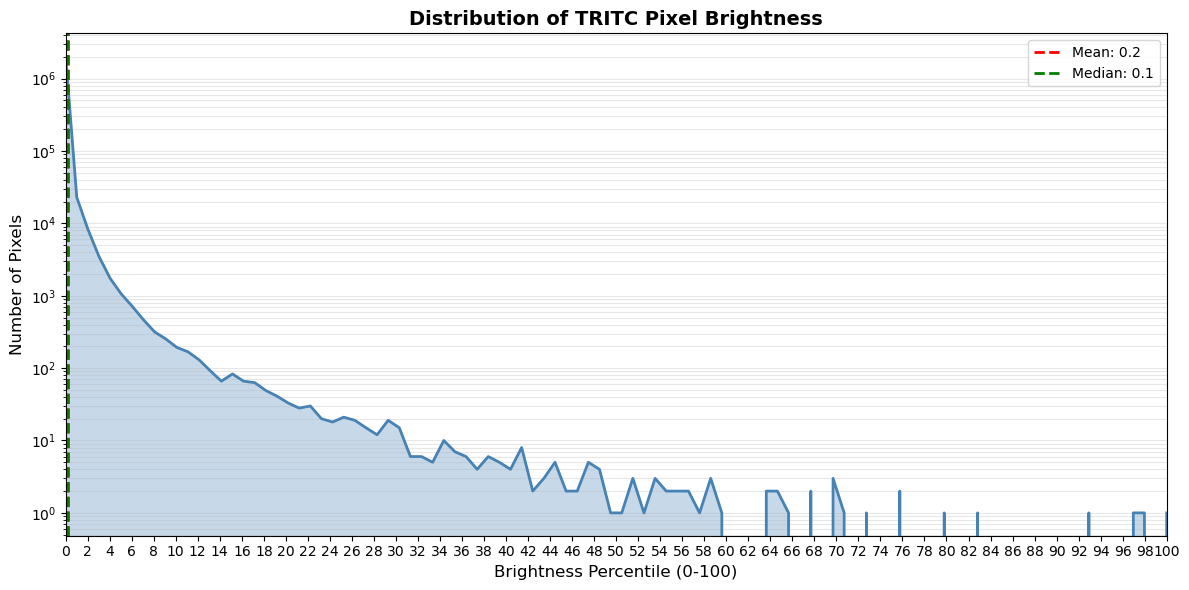

✅ Brightness plot saved



🎯 Enter watershed threshold for TRITC (e.g., 50):  32



📊 Analyzing FITC brightness distribution...

📊 Brightness Statistics:
  Total pixels: 2,095,490
  Mean brightness: 0.16
  Median brightness: 0.12
  Min brightness: 0.00
  Max brightness: 100.00


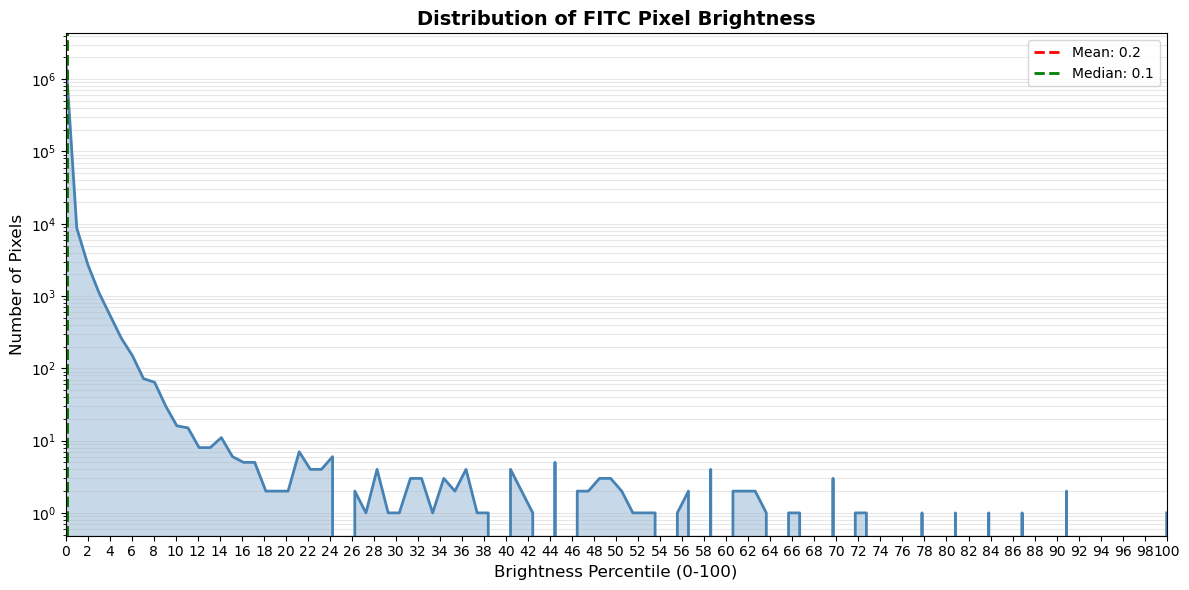

✅ Brightness plot saved



🎯 Enter watershed threshold for FITC (e.g., 50):  26



💡 CALIBRATION REMINDER:
   Add these values to your config at the top of the script:
   MANUAL_WATERSHED_THRESHOLD_TRITC = 32.0
   MANUAL_WATERSHED_THRESHOLD_FITC = 26.0

🚀 Using 8 parallel workers for picture 1/3


Processing nuclei: 100%|███████████████████████████████████████████████████████████████| 49/49 [01:13<00:00,  1.50s/it]


  ✓ Saved: ATR1_24h--W00032--P00015--Z00000--T00000--TRITC_foci.png
  ✓ Saved: ATR1_24h--W00032--P00015--Z00000--T00000--FITC_foci.png
  ✓ Saved: ATR1_24h--W00032--P00015--Z00000--T00000--TRITC_watershed.png
  ✓ Saved: ATR1_24h--W00032--P00015--Z00000--T00000--FITC_watershed.png
✅ Saved 4 global visualizations for Well 00032, Position 00015
Total runtime: 2 minutes and 23.55 seconds


In [ ]:
## Check if the script is the main program(instead of being an imported module), this stops the workers that are spawned below
#for the paralellization from re-running the whole script
if __name__ == '__main__':    
    
    
    #timer to measure how long it takes
    start_time = time.time()
    
    #-----------Delaunay + Sobel-------------#
    
    # load the convex hull(3d shape that contains all the valid parameter iterations) and the 
    # bounding box(max and min of all the parameters of the comvex hull) parameters to iterate through the parameters
    tritc_hull_path = os.path.join(Config.TRITC_PARAMETER_SPACE_PATH, "valid_parameter_hull.pkl")
    with open(tritc_hull_path, "rb") as f:
        delaunay_TRITC = pickle.load(f)

    fitc_hull_path = os.path.join(Config.FITC_PARAMETER_SPACE_PATH, "valid_parameter_hull.pkl")
    with open(fitc_hull_path, "rb") as f:
        delaunay_FITC = pickle.load(f)
    
    # Load separate bounding boxes for each channel
    param_bounds_TRITC = dict(np.load(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\TRITC_parameter_space\parameter_bounds.npz"))
    param_bounds_FITC = dict(np.load(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space\parameter_bounds.npz"))
    
    # Define function to get an ndarray with the shape of the hull saved (find_simplex returns -1, which is outside of the hull shape)
    # This function thus tests if s point is within the convex hull shape(to find valid parameter iterations)
    def in_hull(p, delaunay_obj):
        """
        Test if points are inside a convex hull.
        
        Parameters:
        -----------
        p : ndarray
            Points to test, shape (N, 3) for N points in 3D space
        delaunay_obj : scipy.spatial.Delaunay
            The Delaunay triangulation object representing the convex hull
            
        Returns:
        --------
        ndarray : Boolean array indicating which points are inside the hull
        """
        # Needs delaunay_obj to be a scipy.spatial.Delaunay object
        return delaunay_obj.find_simplex(p) >= 0
    
    
    # ===================================================================
    # GENERATE STRATIFIED PARAMETER SAMPLES FOR TRITC
    # ===================================================================
    print("\n🔸 Generating TRITC parameter samples...")
    Config.N_PARAMETER_SAMPLES = 256  # Target number of samples
    Config.N_SOBOL_SAMPLES = 65536  # 2^17 is maximum recommended, after that diminishing return
    
    # Generate Sobol samples
    sampler_TRITC = qmc.Sobol(d=3, scramble=True)
    unit_samples_TRITC = sampler_TRITC.random(n=Config.N_SOBOL_SAMPLES)
    
    # Scale to TRITC parameter bounds
    scaled_samples_TRITC = qmc.scale(
        unit_samples_TRITC,
        l_bounds=[
            param_bounds_TRITC["bright_pct"][0],
            param_bounds_TRITC["contrast_thresh"][0],
            param_bounds_TRITC["percentile_val"][0],
        ],
        u_bounds=[
            param_bounds_TRITC["bright_pct"][1],
            param_bounds_TRITC["contrast_thresh"][1],
            param_bounds_TRITC["percentile_val"][1],
        ],
    )
    
    # Filter points inside the TRITC Delaunay hull
    inside_mask_TRITC = in_hull(scaled_samples_TRITC, delaunay_TRITC)
    valid_points_TRITC = scaled_samples_TRITC[inside_mask_TRITC]
    n_valid_TRITC = len(valid_points_TRITC)
    
    # Diagnostic output
    print(f"  📊 Hull filtering: {n_valid_TRITC}/{Config.N_SOBOL_SAMPLES} points inside hull ({100*n_valid_TRITC/Config.N_SOBOL_SAMPLES:.1f}%)")
    
    # Check if we have enough points
    if n_valid_TRITC < Config.N_PARAMETER_SAMPLES:
        print(f"\n❌ ERROR: Insufficient valid points in TRITC Delaunay hull!")
        print(f"  • Required: {Config.N_PARAMETER_SAMPLES} points")
        print(f"  • Available: {n_valid_TRITC} points")
        print(f"  • Deficit: {Config.N_PARAMETER_SAMPLES - n_valid_TRITC} points")
        print(f"\n💡 Possible solutions:")
        print(f"  1. Increase Config.N_SOBOL_SAMPLES (current: {Config.N_SOBOL_SAMPLES})")
        print(f"     Try: Config.N_SOBOL_SAMPLES = 65536 (2^16) or 131072 (2^17)")
        print(f"  2. Decrease Config.N_PARAMETER_SAMPLES (current: {Config.N_PARAMETER_SAMPLES})")
        print(f"     Try: Config.N_PARAMETER_SAMPLES = {n_valid_TRITC} or lower")
        print(f"  3. Check your TRITC Delaunay hull:")
        print(f"     • Is the hull too restrictive?")
        print(f"     • Was it trained on sufficient data?")
        print(f"     • File: valid_parameter_hull_TRITC.pkl")
        print(f"  4. Verify parameter bounds are reasonable:")
        print(f"     • Bright %: {param_bounds_TRITC['bright_pct']}")
        print(f"     • Contrast: {param_bounds_TRITC['contrast_thresh']}")
        print(f"     • Percentile: {param_bounds_TRITC['percentile_val']}")
        raise ValueError(f"Cannot generate {Config.N_PARAMETER_SAMPLES} samples from only {n_valid_TRITC} valid points")
    
    # Apply farthest point sampling
    valid_param_samples_TRITC = farthest_point_sampling(valid_points_TRITC, n_samples=Config.N_PARAMETER_SAMPLES)
    total_iterations_TRITC = len(valid_param_samples_TRITC)
    
    # Report success
    print(f"  ✅ Generated {len(valid_param_samples_TRITC)} valid TRITC parameter combinations")
    print(f"    Bright %: {valid_param_samples_TRITC[:,0].min():.1f}-{valid_param_samples_TRITC[:,0].max():.1f}")
    print(f"    Contrast: {valid_param_samples_TRITC[:,1].min():.2f}-{valid_param_samples_TRITC[:,1].max():.2f}")
    print(f"    Percentile: {valid_param_samples_TRITC[:,2].min():.1f}-{valid_param_samples_TRITC[:,2].max():.1f}")
    
    
    # ===================================================================
    # GENERATE STRATIFIED PARAMETER SAMPLES FOR FITC
    # ===================================================================
    print("\n🔸 Generating FITC parameter samples...")
    
    # Generate Sobol samples
    sampler_FITC = qmc.Sobol(d=3, scramble=True)
    unit_samples_FITC = sampler_FITC.random(n=Config.N_SOBOL_SAMPLES)
    
    # Scale to FITC parameter bounds
    scaled_samples_FITC = qmc.scale(
        unit_samples_FITC,
        l_bounds=[
            param_bounds_FITC["bright_pct"][0],
            param_bounds_FITC["contrast_thresh"][0],
            param_bounds_FITC["percentile_val"][0],
        ],
        u_bounds=[
            param_bounds_FITC["bright_pct"][1],
            param_bounds_FITC["contrast_thresh"][1],
            param_bounds_FITC["percentile_val"][1],
        ],
    )
    
    # Filter points inside the FITC Delaunay hull
    inside_mask_FITC = in_hull(scaled_samples_FITC, delaunay_FITC)
    valid_points_FITC = scaled_samples_FITC[inside_mask_FITC]
    n_valid_FITC = len(valid_points_FITC)
    
    # Diagnostic output
    print(f"  📊 Hull filtering: {n_valid_FITC}/{Config.N_SOBOL_SAMPLES} points inside hull ({100*n_valid_FITC/Config.N_SOBOL_SAMPLES:.1f}%)")
    
    # Check if we have enough points
    if n_valid_FITC < Config.N_PARAMETER_SAMPLES:
        print(f"\n❌ ERROR: Insufficient valid points in FITC Delaunay hull!")
        print(f"  • Required: {Config.N_PARAMETER_SAMPLES} points")
        print(f"  • Available: {n_valid_FITC} points")
        print(f"  • Deficit: {Config.N_PARAMETER_SAMPLES - n_valid_FITC} points")
        print(f"\n💡 Possible solutions:")
        print(f"  1. Increase Config.N_SOBOL_SAMPLES (current: {Config.N_SOBOL_SAMPLES})")
        print(f"     Try: Config.N_SOBOL_SAMPLES = 65536 (2^16) or 131072 (2^17)")
        print(f"  2. Decrease Config.N_PARAMETER_SAMPLES (current: {Config.N_PARAMETER_SAMPLES})")
        print(f"     Try: Config.N_PARAMETER_SAMPLES = {n_valid_FITC} or lower")
        print(f"  3. Check your FITC Delaunay hull:")
        print(f"     • Is the hull too restrictive?")
        print(f"     • Was it trained on sufficient data?")
        print(f"     • File: valid_parameter_hull_FITC.pkl")
        print(f"  4. Verify parameter bounds are reasonable:")
        print(f"     • Bright %: {param_bounds_FITC['bright_pct']}")
        print(f"     • Contrast: {param_bounds_FITC['contrast_thresh']}")
        print(f"     • Percentile: {param_bounds_FITC['percentile_val']}")
        raise ValueError(f"Cannot generate {Config.N_PARAMETER_SAMPLES} samples from only {n_valid_FITC} valid points")
    
    # Apply farthest point sampling
    valid_param_samples_FITC = farthest_point_sampling(valid_points_FITC, n_samples=Config.N_PARAMETER_SAMPLES)
    total_iterations_FITC = len(valid_param_samples_FITC)
    
    # Report success
    print(f"  ✅ Generated {len(valid_param_samples_FITC)} valid FITC parameter combinations")
    print(f"    Bright %: {valid_param_samples_FITC[:,0].min():.1f}-{valid_param_samples_FITC[:,0].max():.1f}")
    print(f"    Contrast: {valid_param_samples_FITC[:,1].min():.2f}-{valid_param_samples_FITC[:,1].max():.2f}")
    print(f"    Percentile: {valid_param_samples_FITC[:,2].min():.1f}-{valid_param_samples_FITC[:,2].max():.1f}")
    
    
    # ===================================================================
    # SUMMARY STATISTICS
    # ===================================================================
    print(f"\n📊 Parameter Space Coverage Summary:")
    print(f"  TRITC: {n_valid_TRITC}/{Config.N_SOBOL_SAMPLES} valid points ({100*n_valid_TRITC/Config.N_SOBOL_SAMPLES:.1f}%) → {len(valid_param_samples_TRITC)} selected")
    print(f"  FITC:  {n_valid_FITC}/{Config.N_SOBOL_SAMPLES} valid points ({100*n_valid_FITC/Config.N_SOBOL_SAMPLES:.1f}%) → {len(valid_param_samples_FITC)} selected")
    

    # ===============================================================
    # CALIBRATION MODE LOGIC
    # ===============================================================
    if Config.CALIBRATION_MODE:
        print("\n" + "="*70)
        print("🔧 CALIBRATION MODE ACTIVE")
        print("="*70)
        print(f"Processing first {Config.CALIBRATION_IMAGE_LIMIT if Config.CALIBRATION_IMAGE_LIMIT > 0 else 'ALL'} images")
        print("You will be prompted to enter watershed thresholds for each channel")
        print("After calibration, set CALIBRATION_MODE = False and update")
        print("MANUAL_WATERSHED_THRESHOLD_TRITC and MANUAL_WATERSHED_THRESHOLD_FITC")
        print("="*70 + "\n")
        
        # Determine how many images to process
        num_images_to_process = Config.CALIBRATION_IMAGE_LIMIT if Config.CALIBRATION_IMAGE_LIMIT > 0 else len(DAPI_data)
    else:
        print("\n" + "="*70)
        print("🚀 PRODUCTION MODE ACTIVE")
        print("="*70)
        print(f"Using manual thresholds:")
        print(f"  TRITC: {Config.MANUAL_WATERSHED_THRESHOLD_TRITC}")
        print(f"  FITC:  {Config.MANUAL_WATERSHED_THRESHOLD_FITC}")
        print(f"Visualization generation: {'ENABLED' if Config.GENERATE_VISUALIZATIONS else 'DISABLED'}")
        print(f"Processing all {len(DAPI_data)} images")
        print("="*70 + "\n")
        
        num_images_to_process = len(DAPI_data)
    
    # CREATE LIST TO ACCUMULATE ALL FOCI DATA FOR ALL IMAGES
    all_foci_data = []
    
    # List to add all Data pertaining the Nuclei
    all_nuclei_data = []
     
    
    #High Throughput Data Loading Loop
    for i in range(num_images_to_process):
        print(f"\n{'='*70}")
        print(f"📸 Processing Image {i+1}/{num_images_to_process}")
        print(f"{'='*70}")
        #Loading the picture on i position from each channel
        Cy5_pic = imageio.imread(Cy5_data[i])
        DAPI_pic = imageio.imread(DAPI_data[i])
        DAPI_mask_pic = np.load(DAPI_mask_data[i], allow_pickle=True)
        FITC_pic = imageio.imread(FITC_data[i])
        TRITC_pic = imageio.imread(TRITC_data[i])
    
        # Extract the name of the picture that will be analyzed to later be able to save it accordingly
        base_name = os.path.basename(DAPI_data[i]).removesuffix('DAPI SEM.tif')
    
        # Extract the well number
        # searching the base name for the string --W and then all the numbers 0-9 with \d and the + to look for one or more of the numbers 0-9 with he () it saves them
        well_match = re.search(r'--W(\d+)', base_name)
        # Extracting just the numbers from the previously saved snippet(well_match)
        # group(1) gets just the numbers, group(0) would be with the --W as a prefix. If no numbers are found print of Error
        well_number = well_match.group(1) if well_match else None 
    
        # Extract the Posiiton number --> same principle like extraction of well number extraction
        position_match = re.search(r'--P(\d+)', base_name)
        position_number = position_match.group(1) if well_match else None

        #Warning message in case the well number or position number wasn't able to be extracted
        if well_number is None or position_number is None:
            print(f"Warning: missing Well/Position for file {base_name} (well={well_number}, pos={position_number})")
    
        # Converting the TRITC picture to float to make sure that all the pixel values are compatible with eachother
        TRITC_pic = img_as_float(TRITC_pic)
    
        # Extract the actual mask array
        masks = DAPI_mask_pic  # This contains the segmented regions
    
        
        # ------------------- PARALLEL NUCLEUS PROCESSING ------------------- #
        # Prepare list of nuclei (skip label 0 = background)
        cell_numbers = np.unique(masks)[1:] # This also tells the program where to start with the foci search(that's also why the background was dropped)
        #cell_numbers = [np.unique(masks)[42]]


        if Config.CALIBRATION_MODE:
            # ----- TRITC CALIBRATION -----
            print("\n📊 Analyzing TRITC brightness distribution...")
            sample_isolated = img_as_float(TRITC_pic.copy())
            sample_filtered = filters.difference_of_gaussians(sample_isolated, low_sigma=1, high_sigma=2)
            sample_filtered = np.clip(sample_filtered, 0, None)
            sample_filtered = exposure.rescale_intensity(sample_filtered, in_range='image', 
                                                         out_range=(0, 100))
            
            fig = analyze_brightness_percentiles(sample_filtered, 'TRITC')
            plt.savefig(folder_path+'/'+base_name+'brightness_analysis_TRITC.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("✅ Brightness plot saved")
            
            water_threshold_percentile_TRITC = float(input("\n🎯 Enter watershed threshold for TRITC (e.g., 50): "))
            plt.close(fig)
            
            # ----- FITC CALIBRATION -----
            print("\n📊 Analyzing FITC brightness distribution...")
            sample_isolated = img_as_float(FITC_pic.copy())
            sample_filtered = filters.difference_of_gaussians(sample_isolated, low_sigma=1, high_sigma=2)
            sample_filtered = np.clip(sample_filtered, 0, None)
            sample_filtered = exposure.rescale_intensity(sample_filtered, in_range='image', 
                                                         out_range=(0, 100))
            
            fig = analyze_brightness_percentiles(sample_filtered, 'FITC')
            plt.savefig(folder_path+'/'+base_name+'brightness_analysis_FITC.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("✅ Brightness plot saved")
            
            water_threshold_percentile_FITC = float(input("\n🎯 Enter watershed threshold for FITC (e.g., 50): "))
            plt.close(fig)
            
            # Print reminder to update config after calibration
            print("\n" + "="*70)
            print("💡 CALIBRATION REMINDER:")
            print(f"   Add these values to your config at the top of the script:")
            print(f"   MANUAL_WATERSHED_THRESHOLD_TRITC = {water_threshold_percentile_TRITC}")
            print(f"   MANUAL_WATERSHED_THRESHOLD_FITC = {water_threshold_percentile_FITC}")
            print("="*70 + "\n")
            
        else:
            # ----- PRODUCTION MODE: USE MANUAL THRESHOLDS -----
            water_threshold_percentile_TRITC = Config.MANUAL_WATERSHED_THRESHOLD_TRITC
            water_threshold_percentile_FITC = Config.MANUAL_WATERSHED_THRESHOLD_FITC
            print(f"Using manual thresholds: TRITC={water_threshold_percentile_TRITC}, FITC={water_threshold_percentile_FITC}")
        
        
        # All the channels that will be processed in the worker function below
        channel_images = {
            'TRITC': TRITC_pic,
            'FITC': FITC_pic,
            'Cy5': Cy5_pic,
            'DAPI': DAPI_pic
        }
        # Build argument tuples for each nucleus to send to workers
        # This will be pickled(convert data into a byte stream) to send them to the workers that are generated below
        tasks = [
            (cellnum, masks, channel_images, 
             valid_param_samples_TRITC, valid_param_samples_FITC,
             total_iterations_TRITC, total_iterations_FITC,
             well_number, position_number, 
             water_threshold_percentile_TRITC, water_threshold_percentile_FITC,
             *Config.get_worker_params()  
            )
            for cellnum in cell_numbers
        ]

       
        # Parallel processing 
        # This second main script check is just a safegard before all the workers for the paralellization are spawned(so they don't spawn themselves)
        # CRITICAL for Windows! On Windows ProcessPoolExecutor spawns fresh python interpreters that import the main module and they might re-run the whole thing otherwise
        # Right after you define cell_numbers and before parallel processing:
        if __name__ == '__main__':  
            if Config.MAX_WORKERS is None:
                max_workers = min(8, os.cpu_count() - 1) if os.cpu_count() > 1 else 1
            else:
                max_workers = Config.MAX_WORKERS
            
            print(f"🚀 Using {max_workers} parallel workers for picture {(i+1)}/{len(DAPI_data)}")
            
            from tqdm import tqdm
            
            # ← NEW: Initialize watershed label accumulators (same shape as original mask)
            watershed_labels_tritc = np.zeros_like(masks, dtype=int)
            watershed_labels_fitc = np.zeros_like(masks, dtype=int)
            
            with ProcessPoolExecutor(max_workers=max_workers) as executor:
                futures = {executor.submit(process_single_nucleus, task): task for task in tasks}
                
                for future in tqdm(as_completed(futures), total=len(futures), desc="Processing nuclei"):
                    try:
                        # ← CHANGED: Now expecting 3 return values
                        foci_data_list, nuclei_data_list, watershed_data_list = future.result()
                        
                        all_foci_data.extend(foci_data_list)
                        all_nuclei_data.extend(nuclei_data_list)
                        
                        # ← NEW: Accumulate watershed labels into global arrays
                        for ws_dict in watershed_data_list:
                            cell_id = ws_dict['cell_id']
                            channel = ws_dict['channel']
                            labels = ws_dict['labels']
                            cell_mask = ws_dict['mask']
                            
                            # Place this nucleus's watershed labels into the global array
                            # We need to relabel them to avoid conflicts with other nuclei
                            if channel == 'TRITC':
                                # Get current max label to avoid conflicts
                                max_label = watershed_labels_tritc.max()
                                # Relabel this nucleus's watershed (0 stays 0, others get shifted)
                                relabeled = np.where(labels > 0, labels + max_label, 0)
                                # Place into global array
                                watershed_labels_tritc[cell_mask] = relabeled[cell_mask]
                                
                            elif channel == 'FITC':
                                max_label = watershed_labels_fitc.max()
                                relabeled = np.where(labels > 0, labels + max_label, 0)
                                watershed_labels_fitc[cell_mask] = relabeled[cell_mask]
        
                    except Exception as e:
                        task = futures[future]
                        print(f"❌ Error on nucleus {task[0]}: {e}")
                        import traceback
                        traceback.print_exc()
        
        
            # ===============================================================
            # GLOBAL VISUALIZATION AFTER ALL NUCLEI ARE PROCESSED
            # ===============================================================

            try:
                # Extract foci coordinates from accumulated data
                # After all nuclei are processed, we compile all detected foci coordinates
                # into separate lists for TRITC and FITC channels for visualization
                if all_foci_data:
                    # Convert all foci dictionaries into a pandas DataFrame for easier filtering
                    all_foci_df = pd.DataFrame(all_foci_data)
            
                    # Extract TRITC foci coordinates as list of (y, x) tuples
                    # Filter DataFrame to only TRITC channel and extract y and x coordinates
                    global_foci_TRITC = list(zip(
                        all_foci_df.loc[all_foci_df['channel'] == 'TRITC', 'centr_y'],
                        all_foci_df.loc[all_foci_df['channel'] == 'TRITC', 'centr_x']
                    ))
                    
                    # Extract FITC foci coordinates as list of (y, x) tuples
                    global_foci_FITC = list(zip(
                        all_foci_df.loc[all_foci_df['channel'] == 'FITC', 'centr_y'],
                        all_foci_df.loc[all_foci_df['channel'] == 'FITC', 'centr_x']
                    ))
                else:
                    # If no foci were detected in any nucleus, create empty lists
                    global_foci_TRITC, global_foci_FITC = [], []
            
                # Import the visualization function from the worker module
                from nucleus_worker_Visualization import save_global_visualizations
                
                # Call the visualization function to create 4 output images:
                # 1. TRITC foci as red dots on DAPI background
                # 2. FITC foci as green dots on DAPI background  
                # 3. TRITC watershed regions as filled random colors
                # 4. FITC watershed regions as filled random colors
                save_global_visualizations(
                    original_image=DAPI_pic,                          # Use DAPI as grayscale background
                    foci_tritc=global_foci_TRITC,                     # List of all TRITC foci coordinates
                    foci_fitc=global_foci_FITC,                       # List of all FITC foci coordinates
                    watershed_labels_tritc=watershed_labels_tritc,    # Full-image watershed labels for TRITC
                    watershed_labels_fitc=watershed_labels_fitc,      # Full-image watershed labels for FITC
                    well_number=well_number,                          # Well identifier for filename
                    position_number=position_number,                  # Position identifier for filename
                    base_name=base_name,                              # Original filename base for output naming
                    output_root=folder_path                           # Root directory for saving images
                )
                
                # Print confirmation that all 4 visualization images were saved successfully
                print(f"✅ Saved 4 global visualizations for Well {well_number}, Position {position_number}")
            
            except Exception as e:
                # If visualization fails, print error message but don't crash the entire analysis
                # This allows data saving to continue even if visualization has issues
                print(f"⚠️ Global visualization failed: {e}")
                import traceback
                traceback.print_exc()  # Print full error traceback for debugging
                    

    # Converting all the data that was previously saved in dictionnaries to dataframes to then save them
    # Here all the data that pertains nuclei is converted and then saved
    if all_nuclei_data:
        all_nuclei_df = pd.DataFrame(all_nuclei_data)
        all_nuclei_df = all_nuclei_df.sort_values(['Well', 'Position', 'cell_num']).reset_index(drop=True) #Sorts everything by Well, then Position and then by Cell number
        save_dataframe_to_csv(all_nuclei_df, folder_path, '3_param_iteration', 'nuclei')
    # Here all the data that pertains foci is converted and then saved
    if all_foci_data:
        all_foci_df = pd.DataFrame(all_foci_data)
        all_foci_df = all_foci_df.sort_values(['Well', 'Position', 'cell_num']).reset_index(drop=True) #Sorts everything by Well, then Position and then by Cell number
        save_dataframe_to_csv(all_foci_df, folder_path, '3_param_iteration', 'foci')
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Convert to minutes and seconds for easier reading
    minutes = int(elapsed_time // 60)
    seconds = elapsed_time % 60
    
    print(f"Total runtime: {minutes} minutes and {seconds:.2f} seconds")
    
    '''
    One Nucleus Runtime:
    Before optimization:
    Total runtime: 2 minutes and 17.56 seconds
    After middle part optimization:
    Total runtime: 0 minutes and 4.14 seconds


    734 Pictures:
    Total runtime: 6 hours 14 minutes and 40.45 seconds
    540 Pictures:
    Total runtime: 5 hours 19 minutes and 14.09 seconds


    One Picture runtime all channels: 
    Total runtime: 4 minutes and 42.47 seconds
    '''